# Projet HISTA

In [43]:

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.datasets import load_diabetes, load_breast_cancer, load_wine

SEED = 42

np.random.seed(SEED)  # Pour avoir toujours les mêmes résultats

## Question 1

On reprend les paramètres de l'énoncé et on travaille sur des données standardisées.

In [44]:
# On recopie les paramètres de l'énoncé et on génère les différents paramètres
n = 20
p = 8
beta_star = np.array([5, 3, 0, 0, 1.5, 0, 0, 0])

X = np.random.multivariate_normal(np.zeros(p), np.eye(p), size=n)
epsilon = np.random.normal(0, 1, size=n)
y = X @ beta_star + epsilon

# Nous devons bien standardiser les données comme le dit Tibishirani
# #afin que la pénialité L1 soit équitable entre les coefficients
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Affichage pour vérification
print("Dimensions de X_scaled :", X_scaled.shape)
print("Vecteur beta* :", beta_star)

Dimensions de X_scaled : (20, 8)
Vecteur beta* : [5.  3.  0.  0.  1.5 0.  0.  0. ]


## Question 2

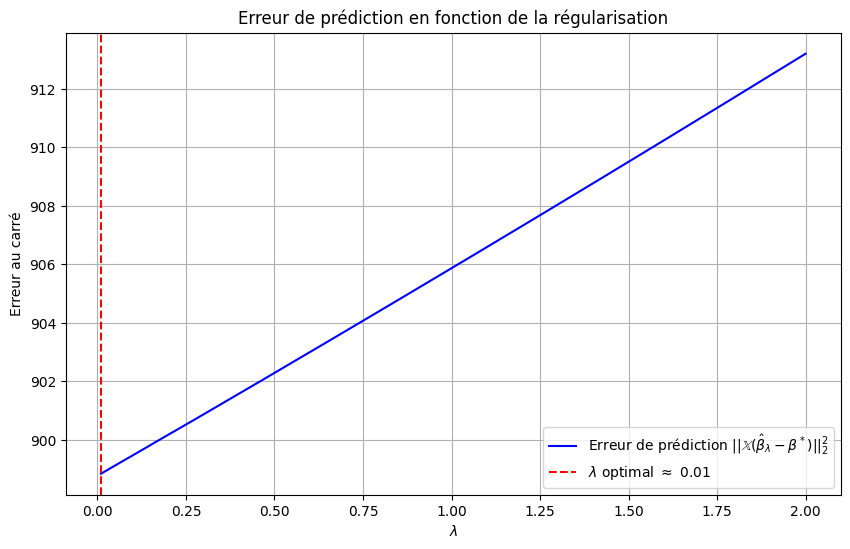

Le lambda optimal (in-sample) est : 0.01


In [45]:
# On définit l'espace pour la fonction comme suggéré dans le rapport
lambdas = np.arange(0.01, 2.01, 0.01)
errors = []
coeffs = []

for l in lambdas:
    # Correspondance avec sklearn : alpha = lambda / (2 * n)
    # pour coller à la formulation RSS + lambda * ||beta||1
    model = Lasso(alpha=l/(2*n), fit_intercept=False, random_state=SEED)
    model.fit(X_scaled, y)

    # Calcul de l'erreur
    y_pred_pure = X_scaled @ model.coef_
    y_true_pure = X_scaled @ (beta_star / scaler.scale_) # On ajuste à l'échelle

    error = np.sum((y_pred_pure - y_true_pure)**2)
    errors.append(error)
    coeffs.append(model.coef_)

# On cherche alors le lambda optimal
idx_opt = np.argmin(errors)
lambda_opt = lambdas[idx_opt]
min_error = errors[idx_opt]

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(lambdas, errors, label='Erreur de prédiction $||\\mathbb{X}(\\hat{\\beta}_\\lambda - \\beta^*)||_2^2$', color='blue')
plt.axvline(x=lambda_opt, color='red', linestyle='--', label=f'$\\lambda$ optimal $\\approx$ {lambda_opt:.2f}')
plt.xlabel('$\\lambda$')
plt.ylabel('Erreur au carré')
plt.title('Erreur de prédiction en fonction de la régularisation')
plt.legend()
plt.grid(True)
plt.show()

print(f"Le lambda optimal (in-sample) est : {lambda_opt:.2f}")

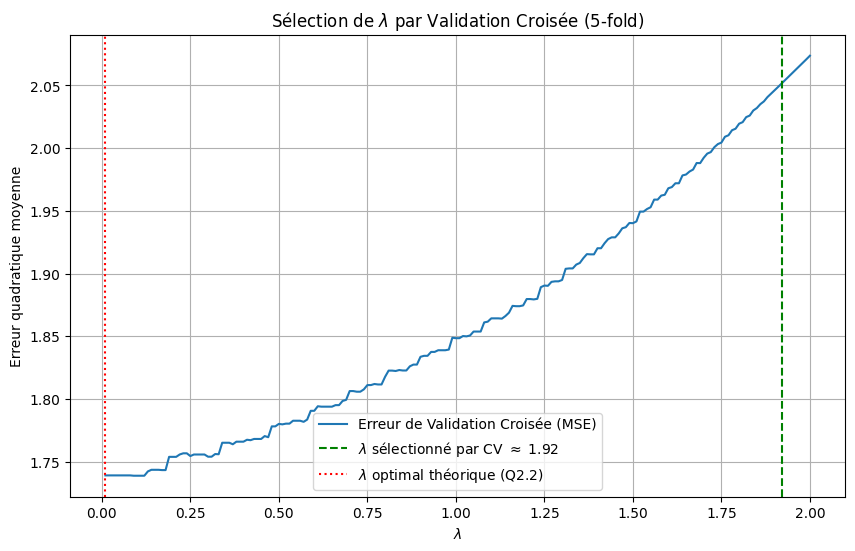

Le lambda sélectionné par CV est : 1.92


In [46]:
# 1. Configuration de la Validation Croisée avec 5 folds comme dans l'article
model_cv = LassoCV(
    alphas=lambdas/(2*n), # Conversion au format sklearn
    cv=5,
    fit_intercept=False,
    max_iter=10000,
    random_state=SEED
)

# Entraînement
model_cv.fit(X_scaled, y)

# Extraction des résultats
lambda_cv = model_cv.alpha_ * (2 * n)
mse_path = model_cv.mse_path_.mean(axis=1) # Moyenne des erreurs sur les 5 folds

# Graphique de comparaison
plt.figure(figsize=(10, 6))
plt.plot(lambdas, mse_path, label='Erreur de Validation Croisée (MSE)')
plt.axvline(x=lambda_cv, color='green', linestyle='--', label=f'$\\lambda$ sélectionné par CV $\\approx$ {lambda_cv:.2f}')
plt.axvline(x=0.01, color='red', linestyle=':', label='$\\lambda$ optimal théorique (Q2.2)')
plt.xlabel('$\\lambda$')
plt.ylabel('Erreur quadratique moyenne')
plt.title('Sélection de $\\lambda$ par Validation Croisée (5-fold)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Le lambda sélectionné par CV est : {lambda_cv:.2f}")

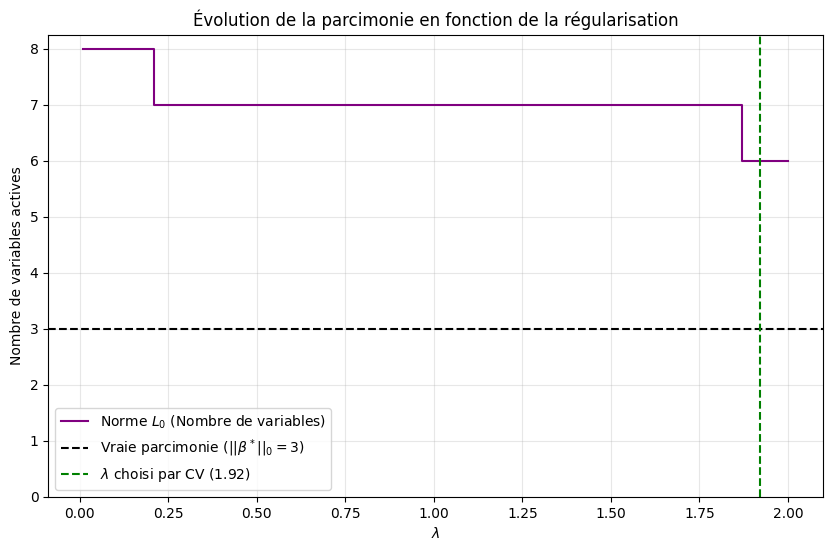

Nombre de variables sélectionnées pour lambda_cv : 6
Indices des variables sélectionnées : [0 1 2 3 4 6]


In [47]:
# Calcul de la norme L0 pour chaque lambda
# On utilise les coefficients déjà calculés à la question 2.2
l0_norms = [np.sum(np.abs(c) > 1e-5) for c in coeffs]

# Visualisation
plt.figure(figsize=(10, 6))
plt.step(lambdas, l0_norms, where='post', color='purple', label='Norme $L_0$ (Nombre de variables)')
plt.axhline(y=3, color='black', linestyle='--', label='Vraie parcimonie ($||\\beta^*||_0 = 3$)')
plt.axvline(x=lambda_cv, color='green', linestyle='--', label=f'$\\lambda$ choisi par CV ({lambda_cv:.2f})')

plt.xlabel('$\\lambda$')
plt.ylabel('Nombre de variables actives')
plt.title('Évolution de la parcimonie en fonction de la régularisation')
plt.yticks(range(0, 9))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Affichage des variables sélectionnées au lambda_cv
best_model_idx = np.abs(lambdas - lambda_cv).argmin()
selected_vars = np.where(np.abs(coeffs[best_model_idx]) > 1e-5)[0]
print(f"Nombre de variables sélectionnées pour lambda_cv : {l0_norms[best_model_idx]}")
print(f"Indices des variables sélectionnées : {selected_vars}")

## Question 3

On travaille ici sur des données réelles de classification (cancer du sein). La cible est binaire, ce qui justifie l'utilisation d'une régression logistique avec pénalité Lasso.

In [48]:
# Chargement des données depuis le dépôt UCI
# Documentation : https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

from ucimlrepo import fetch_ucirepo

breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets['Diagnosis']

features = X.columns

print(breast_cancer_wisconsin_diagnostic.metadata)


{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [49]:
# Aperçu des données
print(X.head(5))
print(y.head(5))


   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  radius3  \
0      0.3001          0.14710     0.2419             0.07871  ...    25.38   
1      0.0869          0.07017     0.1812             0.05667  ...    24.99   
2      0.1974          0.12790     0.2069             0.05999  ...    23.57   
3      0.2414          0.10520     0.2597             0.09744  ...    14.91   
4      0.1980          0.10430     0.1809             0.05883  ...    22.54   

   texture3  perimeter3   area3  smoothness3  compactness3  concavity3  \
0     17.33      184.60 

La cible est binaire (M = malin, B = bénin), ce qui justifie l'utilisation d'une régression logistique. Cela correspond exactement à la section 8.1 de l'article, qui étend le Lasso au cadre de la vraisemblance maximale pénalisée.

In [50]:
# Prétraitement des données
y_encoded = np.where(y == 'M', 1, 0)  # Encodage binaire de la cible (M=1, B=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [51]:
# Lasso logistique : chemin de régularisation
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV

# sklearn utilise C = 1/lambda, contrairement à la convention de l'exercice 1
Cs = 1 / lambdas

coefs = []
for c in Cs:
    # Le solver liblinear est requis pour la pénalité L1
    clf = LogisticRegression(penalty='l1', C=c, solver='liblinear', random_state=SEED)
    clf.fit(X_scaled, y_encoded)
    coefs.append(clf.coef_[0])


/home/epsilon/anaconda3/envs/machine_learning_no_cuda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/epsilon/anaconda3/envs/machine_learning_no_cuda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/home/epsilon/anaconda3/envs/machine_learning_no_cuda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use 

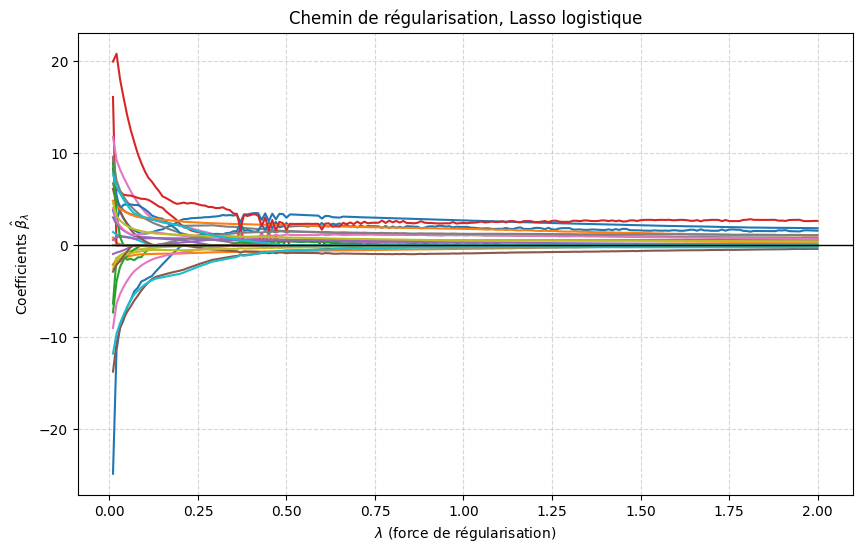

In [52]:
coefs = np.array(coefs)

plt.figure(figsize=(10, 6))
for i in range(coefs.shape[1]):
    plt.plot(lambdas, coefs[:, i])

plt.xlabel(r'$\lambda$ (force de régularisation)')
plt.ylabel(r'Coefficients $\hat{\beta}_\lambda$')
plt.title('Chemin de régularisation, Lasso logistique')
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.axhline(0, color='black', linewidth=1)
plt.show()


In [53]:
clf_cv = LogisticRegressionCV(Cs=Cs, cv=5, penalty='l1', solver='liblinear', max_iter=10000, random_state=SEED)
clf_cv.fit(X_scaled, y_encoded)

best_C = clf_cv.C_[0]
best_lambda = 1 / best_C

print(f'Valeur optimale de C : {best_C:.4f}')
print(f'Lambda optimal : {best_lambda:.4f}\n')

# Coefficients au lambda optimal
optimal_coefs = clf_cv.coef_[0]
active_mask = optimal_coefs != 0
active_vars = features[active_mask]
active_weights = optimal_coefs[active_mask]

print(f'Variables actives ({len(active_vars)} sur 30) :')
# Tri par valeur absolue décroissante
sorted_indices = np.argsort(np.abs(active_weights))[::-1]
for idx in sorted_indices:
    print(f'{active_vars[idx]:<25}: {active_weights[idx]:.4f}')


/home/epsilon/anaconda3/envs/machine_learning_no_cuda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/home/epsilon/anaconda3/envs/machine_learning_no_cuda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/home/epsilon/anaconda3/envs/machine_learning_no_cuda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV w

Valeur optimale de C : 1.0000
Lambda optimal : 1.0000

Variables actives (16 sur 30) :
radius2                  : 2.7061
area3                    : 2.4350
radius3                  : 2.0072
texture3                 : 1.7787
concave_points3          : 1.2510
concavity3               : 1.1081
concave_points1          : 1.0976
compactness2             : -0.8757
symmetry3                : 0.5541
smoothness3              : 0.5478
texture2                 : -0.3866
smoothness2              : 0.3183
fractal_dimension2       : -0.2346
fractal_dimension1       : -0.1237
concavity1               : 0.1148
perimeter3               : 0.0446


## Bonus, version A : Lasso seul

Un **chemin de régularisation** trace l'évolution des coefficients $\hat\beta_j(\lambda)$ lorsque $\lambda$ varie de petit (peu de régularisation) à grand (modèle nul). On illustre ici le chemin Lasso sur les trois jeux de données réels. Les coefficients dont la trajectoire est **non-monotone** (leur valeur absolue remonte à un moment donné lorsque $\lambda$ croît) sont tracés en rouge.

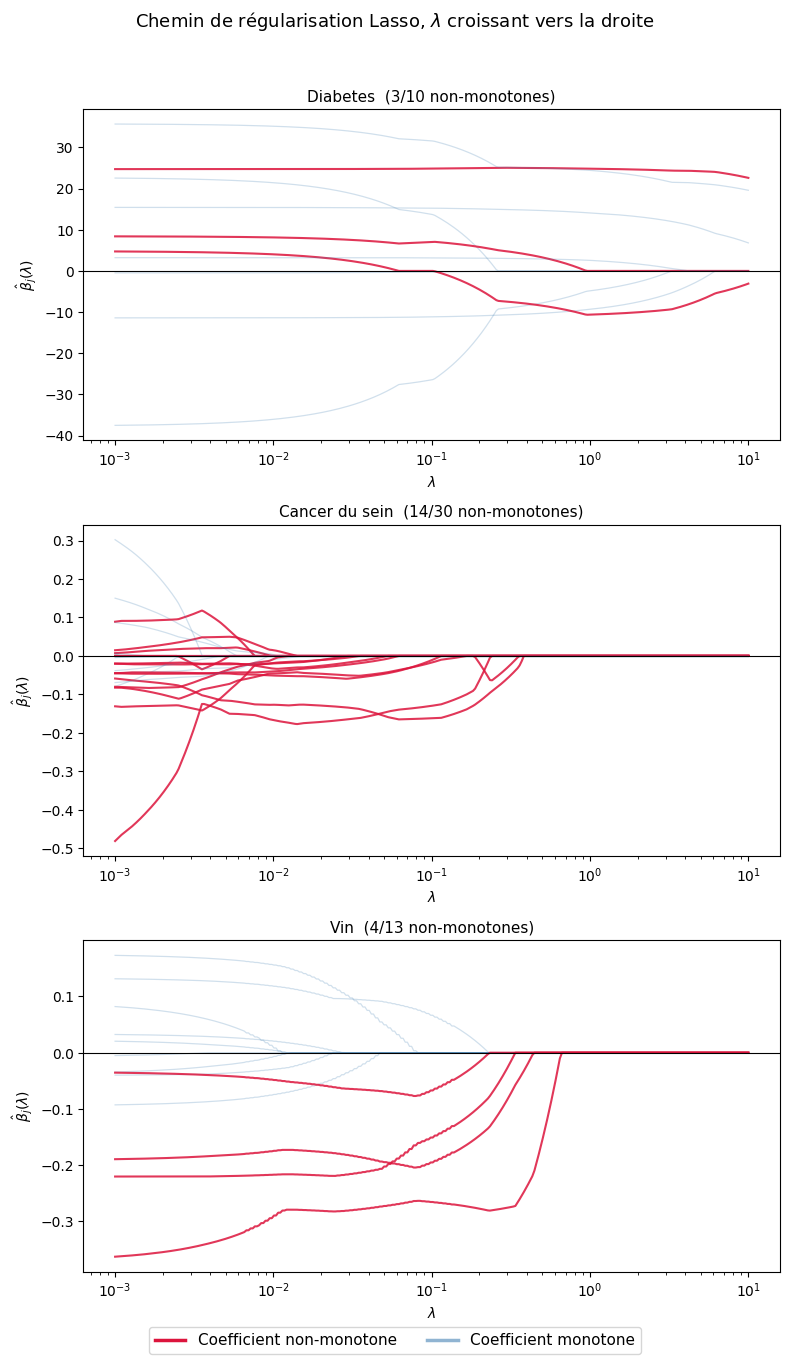

In [54]:
from sklearn.linear_model import lasso_path

alphas_path = np.logspace(1, -3, 300)

DATASETS_BONUS = [
    ('Diabetes',       load_diabetes()),
    ('Cancer du sein', load_breast_cancer()),
    ('Vin',            load_wine()),
]

def detect_non_monotone(coefs_desc, tol=1e-6):
    return np.any(np.diff(np.abs(coefs_desc), axis=1) < -tol, axis=1)

fig, axes = plt.subplots(3, 1, figsize=(8, 13))
fig.suptitle(
    r'Chemin de régularisation Lasso, $\lambda$ croissant vers la droite',
    fontsize=13, y=1.02
)

for row, (ds_name, data) in enumerate(DATASETS_BONUS):
    X_d = StandardScaler().fit_transform(data.data)
    y_d = data.target.astype(float)
    y_d -= y_d.mean()
    p_d = X_d.shape[1]

    alphas_lasso, coefs_lasso, _ = lasso_path(X_d, y_d, alphas=alphas_path)
    mask_lasso = detect_non_monotone(coefs_lasso)
    lam_plot = alphas_lasso[::-1]
    coefs_plot = coefs_lasso[:, ::-1]
    n_nm = int(mask_lasso.sum())

    ax = axes[row]
    for j in range(p_d):
        color = 'crimson' if mask_lasso[j] else 'steelblue'
        alpha = 0.85 if mask_lasso[j] else 0.25
        lw    = 1.5  if mask_lasso[j] else 0.9
        ax.plot(lam_plot, coefs_plot[j], color=color, alpha=alpha, lw=lw)

    ax.axhline(0, color='black', lw=0.8)
    ax.set_xscale('log')
    ax.set_title(f'{ds_name}  ({n_nm}/{p_d} non-monotones)', fontsize=11)
    ax.set_xlabel(r'$\lambda$', fontsize=10)
    ax.set_ylabel(r'$\hat\beta_j(\lambda)$', fontsize=10)

from matplotlib.lines import Line2D
fig.legend(handles=[
    Line2D([0], [0], color='crimson',   lw=2.5, label='Coefficient non-monotone'),
    Line2D([0], [0], color='steelblue', lw=2.5, alpha=0.6, label='Coefficient monotone'),
], loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()


## Bonus, version B : Lasso et Ridge

On compare ici les chemins Lasso et Ridge côte à côte sur les mêmes jeux de données. Le Lasso (pénalité $L_1$) peut produire des trajectoires **non-monotones** car la boule $L_1$ est un polyèdre à coins : lorsqu'une variable entre ou sort du support actif, les coefficients de ses voisines corrélées peuvent s'inverser temporairement. Ridge (pénalité $L_2$) reste quasi-monotone car la boule $L_2$ est lisse, sans coins ni arêtes. Avec des données réelles, on peut observer des trajectoires non-monotones pour le Ridge aussi, parce que les variables peuvent être très corrélées, qui est une violation de l'hypothèse d'indépendance des features.

Les coefficients dont la trajectoire est **non-monotone** sont tracés en rouge.

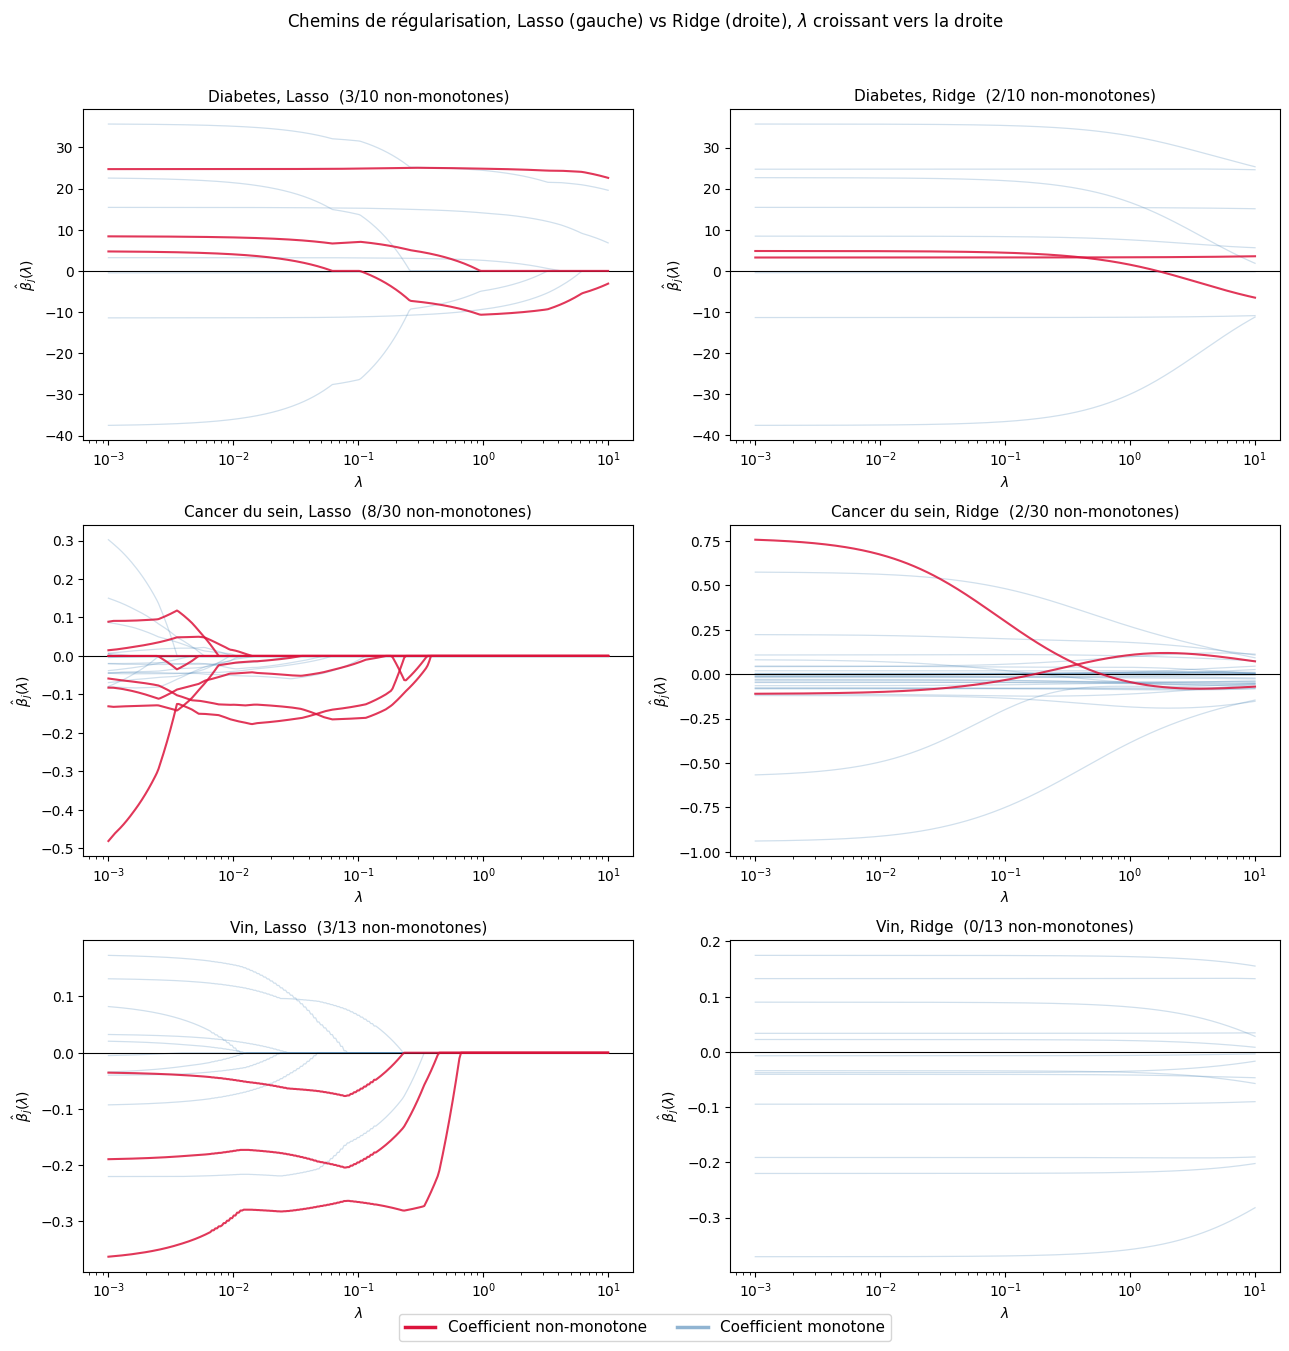

Synthese, coefficients non-monotones detectes :
Jeu de données                Lasso        Ridge
------------------------------------------------
Diabetes                  3/10          2/10    
Cancer du sein            8/30          2/30    
Vin                       3/13          0/13    


In [55]:
from sklearn.linear_model import lasso_path, Ridge
from matplotlib.lines import Line2D

alphas_path = np.logspace(1, -3, 300)

DATASETS_BONUS = [
    ('Diabetes',       load_diabetes()),
    ('Cancer du sein', load_breast_cancer()),
    ('Vin',            load_wine()),
]

# tol=1e-3 pour éviter les faux positifs dus au bruit numérique des fits indépendants
def detect_non_monotone(coefs_desc, tol=1e-3):
    return np.any(np.diff(np.abs(coefs_desc), axis=1) < -tol, axis=1)

results_summary = {}

fig, axes = plt.subplots(3, 2, figsize=(13, 13))
fig.suptitle(
    r'Chemins de régularisation, Lasso (gauche) vs Ridge (droite), $\lambda$ croissant vers la droite',
    fontsize=12, y=1.02
)

for row, (ds_name, data) in enumerate(DATASETS_BONUS):
    X_d = StandardScaler().fit_transform(data.data)
    y_d = data.target.astype(float)
    y_d -= y_d.mean()
    p_d = X_d.shape[1]

    # Lasso path
    alphas_lasso, coefs_lasso, _ = lasso_path(X_d, y_d, alphas=alphas_path)
    mask_lasso = detect_non_monotone(coefs_lasso)

    # Ridge path via sklearn
    coefs_ridge = np.column_stack([
        Ridge(alpha=a, fit_intercept=False).fit(X_d, y_d).coef_
        for a in alphas_path
    ])
    mask_ridge = detect_non_monotone(coefs_ridge)

    results_summary[ds_name] = (p_d, int(mask_lasso.sum()), int(mask_ridge.sum()))

    lam_plot = alphas_lasso[::-1]

    for col, (coefs_desc, mask, label) in enumerate([
        (coefs_lasso, mask_lasso, 'Lasso'),
        (coefs_ridge, mask_ridge, 'Ridge'),
    ]):
        ax = axes[row, col]
        coefs_plot = coefs_desc[:, ::-1]
        n_nm = int(mask.sum())

        for j in range(p_d):
            color = 'crimson' if mask[j] else 'steelblue'
            alpha = 0.85 if mask[j] else 0.25
            lw    = 1.5  if mask[j] else 0.9
            ax.plot(lam_plot, coefs_plot[j], color=color, alpha=alpha, lw=lw,
                    zorder=3 if mask[j] else 1)

        ax.axhline(0, color='black', lw=0.8, zorder=2)
        ax.set_xscale('log')
        ax.set_title(f'{ds_name}, {label}  ({n_nm}/{p_d} non-monotones)', fontsize=11)
        ax.set_xlabel(r'$\lambda$', fontsize=10)
        ax.set_ylabel(r'$\hat\beta_j(\lambda)$', fontsize=10)

fig.legend(handles=[
    Line2D([0], [0], color='crimson',   lw=2.5, label='Coefficient non-monotone'),
    Line2D([0], [0], color='steelblue', lw=2.5, alpha=0.6, label='Coefficient monotone'),
], loc='lower center', ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.01))
plt.tight_layout()
plt.show()

print('Synthese, coefficients non-monotones detectes :')
print(f'{"Jeu de données":<22} {"Lasso":>12} {"Ridge":>12}')
print('-' * 48)
for name, (p_d, nl, nr) in results_summary.items():
    print(f'{name:<22} {nl:>4}/{p_d:<6}   {nr:>4}/{p_d:<6}')
